In [1]:
# Imports
import ROOT
import array

from tools import scale_out as so

from emm import data
from emm import fitting
from emm import models
from emm import bias

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

Welcome to JupyROOT 6.30/04


# Dijet

In [2]:
# Load the data
h_obs, h_fit = data.get_dijet_data()
n_obs = h_obs.Integral()

# Get binning from data
xaxis = h_obs.GetXaxis()
boundaries = [xaxis.GetBinLowEdge(i) for i in range(1, xaxis.GetNbins() + 2)]
binning = ROOT.RooBinning(len(boundaries) - 1, array.array('d', boundaries))

x = ROOT.RooRealVar("x", "Dijet Mass [GeV]", boundaries[0], boundaries[-1])
x.setBinning(binning)

dijet_data = ROOT.RooDataHist("ATLAS_dijet_data", "ATLAS dijet data", ROOT.RooArgList(x), h_obs)
print(f"Data mean: {dijet_data.mean(x)}")

# SW -- Dijet Paper Fit
dh_fit = ROOT.RooDataHist("dh_fit", "dh_fit", ROOT.RooArgList(x), h_fit)
pdf_fit = ROOT.RooHistPdf("pdf_fit", "pdf_fit", ROOT.RooArgSet(x), dh_fit)

fit_options = [
    ROOT.RooFit.IntegrateBins(0.001),
    ROOT.RooFit.PrintLevel(-1),
    # ROOT.RooFit.Offset(True),
    # ROOT.RooFit.Strategy(2),
    ROOT.RooFit.Save(),
    # ROOT.RooFit.Range("fit_range")
]

Data mean: 1347.5082817871998


In [3]:
# Set up models
toy_models = [
    models.Dijet(x)
]

model_primitives = [
    models.ModelPrimitive(models.Dijet)
]
for k in [3, 4, 5]:
    model_primitives.append(
        models.ModelPrimitive(
            models.ExponentialMixtureModel,
            k,
            data_mean=1347,
            name=f"ExponentialMixture-{k}",
        )
    )

# Fit toy models to data
for toy_model in toy_models:
    print(f"Fitting toy model: {toy_model.name}")
    toy_model.pdf.fitTo(dijet_data, *fit_options)

Fitting toy model: Dijet
[#1] INFO:NumericIntegration -- RooRealIntegral::init(Dijet_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization


In [4]:
# Configuration
x_min, x_max = 1100, 10000
x_grid = np.linspace(x_min, x_max, 1000)

# Default
n_seeds = 100
n_toys_per_seed = 5
n_restarts = 100
n_retries = 30

# Test
# n_seeds = 4
# n_toys_per_seed = 1
# n_restarts = 10
# n_retries = 30

# Generate seeds
default_seed = 42
np.random.seed(default_seed)
seeds = np.random.randint(0, 10000, size=n_seeds)

In [ ]:
# Run jobs
tasks = []
for seed in seeds:
    for toy_model in toy_models:
        tasks.append(
            so.Task(
                bias.run_bias_fits,
                x, toy_model, model_primitives,
                seed, n_toys_per_seed,
                n_obs, x_grid,
                n_restarts, n_retries,
                fit_options=fit_options,
                bin_toy_data=True,
                print_level=4,
                cache_tag="dijet",
            )
        )

_ = so.run_tasks(
    tasks,
    use_condor=True,
    condor_job_name="bias",
    env_wrapper=so.run_in_mamba,
    clear_logs=True
)

Submitting 100 tasks to condor with job name 'bias'


In [ ]:
# Load results
results = bias.get_bias_results(
    toy_models,
    seeds,
    n_toys_per_seed,
    n_obs,
    cache_tag="dijet",
 )

[#1] INFO:NumericIntegration -- RooRealIntegral::init(Dijet_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)


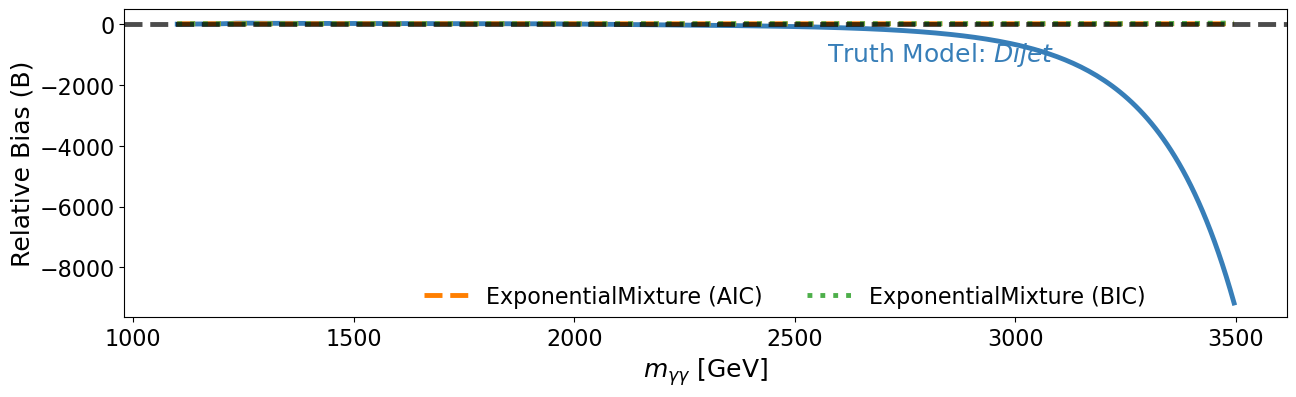

In [6]:
_ = bias.plot_bias(
    x,
    toy_models,
    results,
    x_grid,
    range=(500, 3500),
    legend_fontsize=16,
)

# Diphoton

In [4]:
# # Load data
x = ROOT.RooRealVar("x", "Diphoton Mass [GeV]", 500, 10_000)
data_tree = data.get_diphoton_data( tree=True)
data = ROOT.RooDataSet("mgg", "mgg", ROOT.RooArgSet(x), ROOT.RooFit.Import(data_tree))
n = data.numEntries()
data_mean = data.mean(x)
print(f"Data mean: {data_mean}")

Data mean: 676.7652379849756


In [5]:
# Configuration
x_min, x_max = 500, 3500
x_grid = np.linspace(x_min, x_max, 1000)

# Default
n_seeds = 50
n_toys_per_seed = 100

# Generate seeds
default_seed = 42
np.random.seed(default_seed)
seeds = np.random.randint(0, 10000, size=n_seeds)

In [6]:
# Set up models
toy_models = [
    models.f1(x),
    models.f2(x),
    models.f3(x),
    models.f4(x),
]

model_primitives = [
    models.ModelPrimitive(models.f1),
    models.ModelPrimitive(models.f2),
    models.ModelPrimitive(models.f3),
    models.ModelPrimitive(models.f4)
]
for k in [2, 3, 4]:
    model_primitives.append(
        models.ModelPrimitive(
            models.ExponentialMixtureModel,
            k,
            data_mean=700,
            name=f"ExponentialMixture-{k}",
        )
    )

print(f"Will be submitting {n_seeds * len(toy_models)} tasks, with {n_toys_per_seed} toys fitting {len(model_primitives)} models.")

# Fit toy models to data
for toy_model in toy_models:
    print(f"Fitting toy model: {toy_model.name}")
    toy_model.pdf.fitTo(data)

Will be submitting 200 tasks, with 100 toys fitting 7 models.
Fitting toy model: f_1
Fitting toy model: f_2
Fitting toy model: f_3
Fitting toy model: f_4
[#1] INFO:NumericIntegration -- RooRealIntegral::init(f_1_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
Minuit2Minimizer: Minimize with max-calls 1000 convergence for edm < 1 strategy 1
Minuit2Minimizer : Valid minimum - status = 1
FVAL  = 31033.2097955985919
Edm   = 0.000159485240499530157
Nfcn  = 27
p1	  = 5.71808	 +/-  0.898473	(limited)
p2	  = -0.778647	 +/-  0.0667606	(limited)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:NumericIntegration -- RooRealIntegral::init(f_2_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
Minuit2Minimizer

Info in <Minuit2>: MnSeedGenerator Computing seed using NumericalGradient calculator
Info in <Minuit2>: MnSeedGenerator Initial state: FCN =       31033.41007 Edm =      0.4026341363 NCalls =      9
Info in <Minuit2>: MnSeedGenerator Initial state  
  Minimum value : 31033.41007
  Edm           : 0.4026341363
  Internal parameters:	[   -0.06003605845    -0.1202898824]	
  Internal gradient  :	[      -55.0368949     -36.51043855]	
  Internal covariance matrix:
[[  0.00026610788              0]
 [              0  0.00060350528]]]
Info in <Minuit2>: VariableMetricBuilder Start iterating until Edm is < 0.001 with call limit = 1000
Info in <Minuit2>: VariableMetricBuilder    0 - FCN =       31033.41007 Edm =      0.4026341363 NCalls =      9
Info in <Minuit2>: VariableMetricBuilder    1 - FCN =        31033.2098 Edm =   3.319820566e-06 NCalls =     15
Warning in <Minuit2>: MnPosDef Matrix forced pos-def by adding to diagonal 0.00459152
Info in <Minuit2>: VariableMetricBuilder After Hessian
I

In [ ]:
# Run jobs
tasks = []
for seed in seeds:
    for toy_model in toy_models:
        tasks.append(so.Task(bias.run_bias_fits, x, toy_model, model_primitives, seed, n_toys_per_seed, n, x_grid, cache_tag="diphoton"))

# _ = so.run_tasks(
#     tasks,
#     use_condor=True,
#     condor_job_name="bias",
#     env_wrapper=so.run_in_mamba,
#     clear_logs=True
# )

In [ ]:
# Load and combine results
results = bias.get_bias_results(
    toy_models,
    seeds,
    n_toys_per_seed,
    n,
    cache_tag="diphoton",
 )

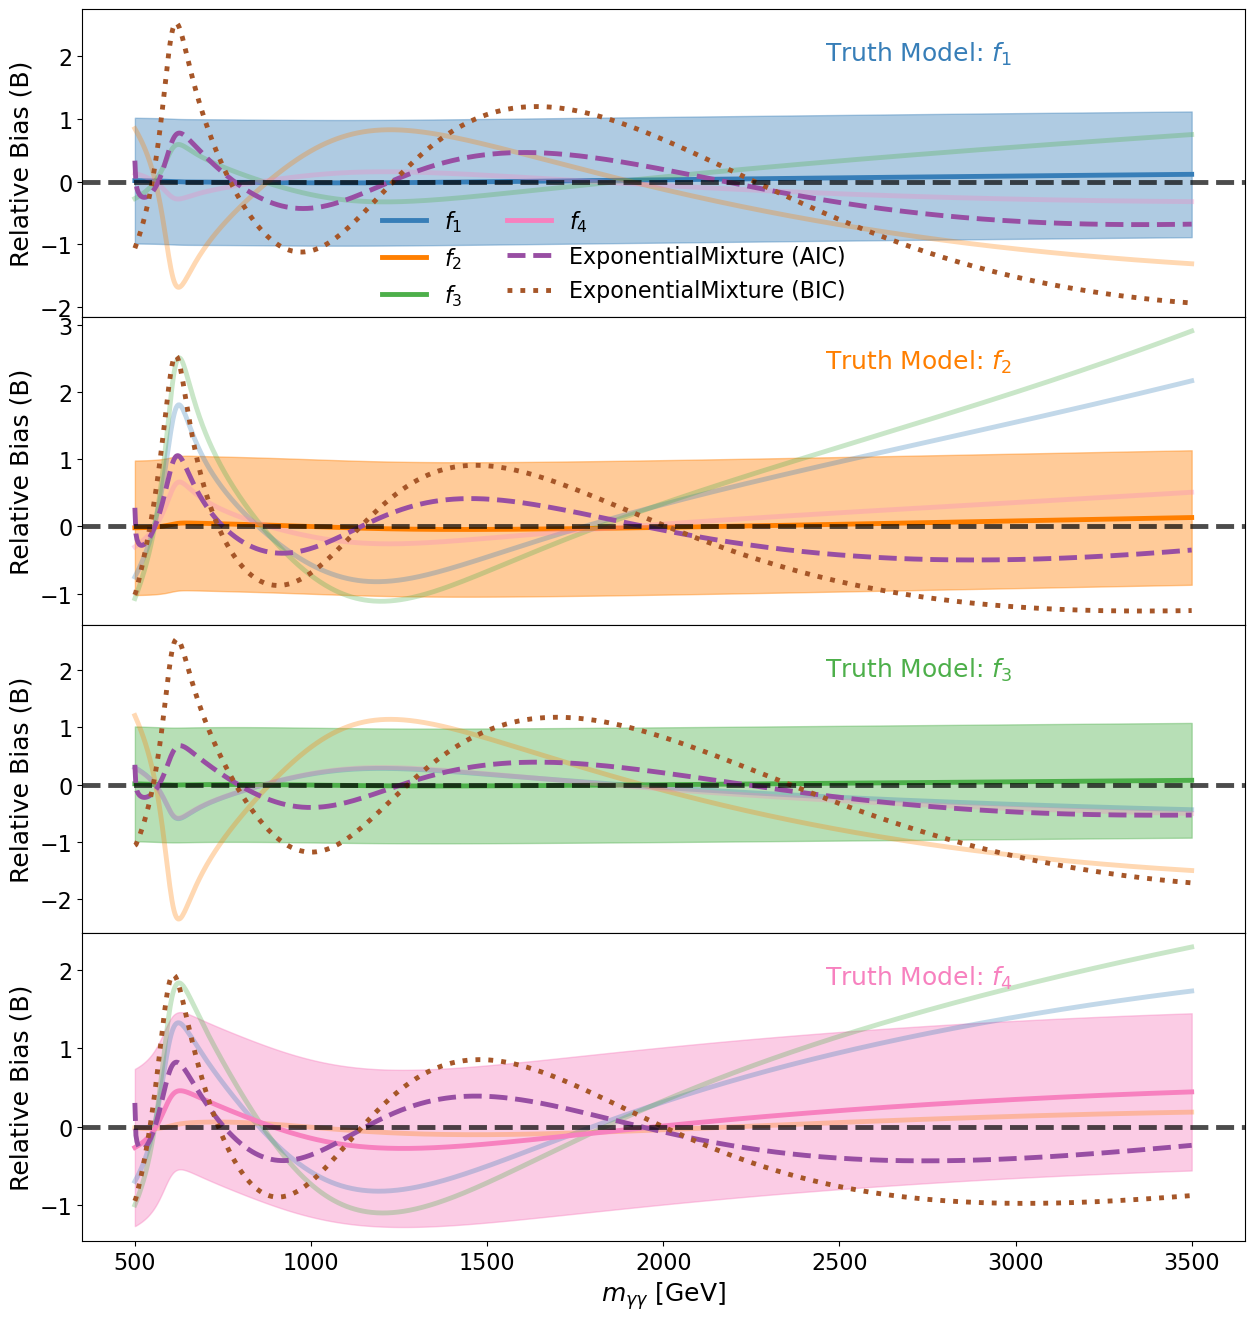

In [10]:
_ = bias.plot_bias(
    x,
    toy_models,
    results,
    x_grid,
    range=(500, 3500),
    legend_fontsize=16,
)